In [319]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [320]:
df = pd.read_csv('/PyAi/okKelulusan Siswa.csv')
df.head()

,ID,Jam_Belajar,Kehadiran,Nilai_Tugas,Ikut_Bimbel,Warna_Tas,Nomor_Kursi,Lulus
0,1,5.0,90.0,85.0,Ya,Merah,12,Ya
1,2,2.0,60.0,65.0,Tidak,Biru,7,Tidak
2,3,4.0,80.0,75.0,Ya,Hitam,3,Ya
3,4,1.0,50.0,60.0,Tidak,Hijau,18,Tidak
4,5,6.0,95.0,90.0,Ya,Biru,9,Ya


In [329]:
df.info()

<class 'pandas.DataFrame'>
Index: 54 entries, 0 to 59
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   ID           54 non-null     int64  
 1   Jam_Belajar  54 non-null     float64
 2   Kehadiran    54 non-null     float64
 3   Nilai_Tugas  54 non-null     float64
 4   Ikut_Bimbel  54 non-null     int64  
 5   Warna_Tas    54 non-null     str    
 6   Nomor_Kursi  54 non-null     int64  
 7   Lulus        54 non-null     int64  
dtypes: float64(3), int64(4), str(1)
memory usage: 3.8 KB


#### datasaset tersebut terdiri dari 60 baris dan 8 kolom. memiliki 6 atribut meliputi ID,jam belajar,kehadiran,kehadiran,nilai tugas,ikut bimbel,warna tas. Lalu 1 Target yaitu Lulus atau tidak lulus. Data type terdiri 3 jenis meliputi integer 2 (ID, nama kursi), float 3(jam belajar, kehadiran, nilai tugas), string 3 (ikut bimbel, warna tas), terdapat 2 data yang missing value pada atribut Jam_Belajar, 1 pada kehadira, dan 3 pada nilai tugas. ini dapat dihitung melalui max data record 60 dan data yang tidak mencapai angka 60 berarti sisanya termasuk missing value

In [324]:
df.dropna(inplace=True)

#### menghapus missing value, sebab nilai yang kosong akan berpengaruh pada bagaimana data akan dapat dibaca pada kkomputer dan nilai kosong berarti juga tidak digunakan, inplace=True berarti menghapus tanpa membuat dataframe baru ibaratnya tidak ada jejak

In [325]:
df.duplicated().sum()

np.int64(0)

#### mengecek apakah ada data yang duplikat dan dapat dilihat bahwa tidak ada data duplikat sebab nilainya 0. Data yang duplikat harus dicari sebab data yang sama tidak akan membuat model memiliki akurasi yang tinggi, tetapi akan membuat model tidak belajar dengan baik karena diberi contoh yang sama

In [327]:
cat_cols = ['Ikut_Bimbel', 'Lulus']

for col in cat_cols:
    labels = df[col].dropna().unique()
    mapping = {label: i for i, label in enumerate(labels)}
    df[col] = df[col].map(mapping)

#### tahapan ini yaitu one hot encoding, yaitu mengubah data kategori menjadi numerik,mengapa? sebab ketika dilangkah selanjutnya kita membutuhkan data atribut berupa numerik. pada bagian ini atribut Ikut_Bimbel dan Lulus akan diubah ke kategori. lalu mengapa warna tas tidak? karena warna tas tidak berpengaruh pada target/label yang akan kita olah

In [328]:
df.head()

,ID,Jam_Belajar,Kehadiran,Nilai_Tugas,Ikut_Bimbel,Warna_Tas,Nomor_Kursi,Lulus
0,1,5.0,90.0,85.0,0,Merah,12,0
1,2,2.0,60.0,65.0,1,Biru,7,1
2,3,4.0,80.0,75.0,0,Hitam,3,0
3,4,1.0,50.0,60.0,1,Hijau,18,1
4,5,6.0,95.0,90.0,0,Biru,9,0


#### untuk mengecek apakah encoding telah berhasil apa belum? dan tentu saja disini berhasil sebab data telah menjadi numerik. siswa yang ikut bimbel akan ditandai dengan angka 1 dan siswa yang tidak iku bimbel akan ditandai dengan angka 0. begitupun juga berlaku pada label lulus

In [318]:
FEATURE = ["Jam_Belajar", "Kehadiran", "Nilai_Tugas", "Ikut_Bimbel"]
TARGET = "Lulus"

x = df[FEATURE].to_numpy(dtype=float)
y = df[TARGET].to_numpy()

print("Jam_Belajar:", len(df))
print(["Kehadiran", "Nilai_Tugas", "Ikut_Bimbel"], FEATURE)
print("Lulus", TARGET)
print("Contoh label unik", np.unique(y))

Jam_Belajar: 54
['Kehadiran', 'Nilai_Tugas', 'Ikut_Bimbel'] ['Jam_Belajar', 'Kehadiran', 'Nilai_Tugas', 'Ikut_Bimbel']
Lulus Lulus
Contoh label unik [0 1]


#### pada tahap ini menentukan mana fitur dan mana target, bednya yaitu atribut fitur ialah atribut yang paling mempengaruhi keputusn suatu target, atribut ID, warna tas, dan nomor kursi tidak berpengaruh pada target. 

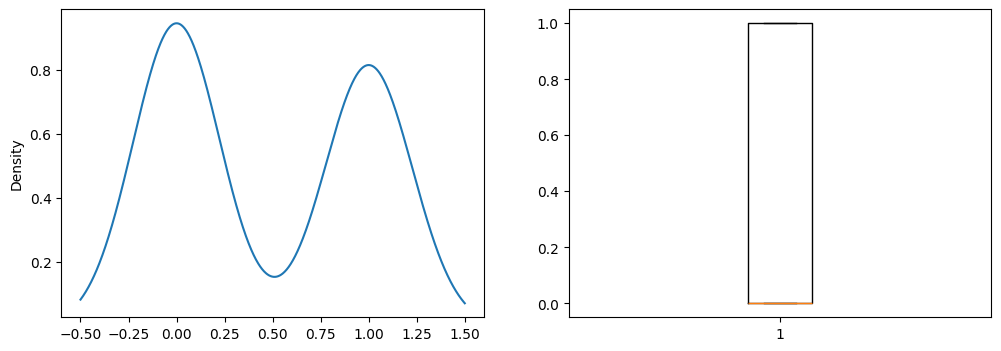

In [297]:
f= plt.figure(figsize=(12,4))
f.add_subplot(1,2,1)
df['Lulus'].plot(kind='kde')
f.add_subplot(1,2,2)
plt.boxplot(df['Lulus'])
plt.show()

<Axes: xlabel='Lulus'>

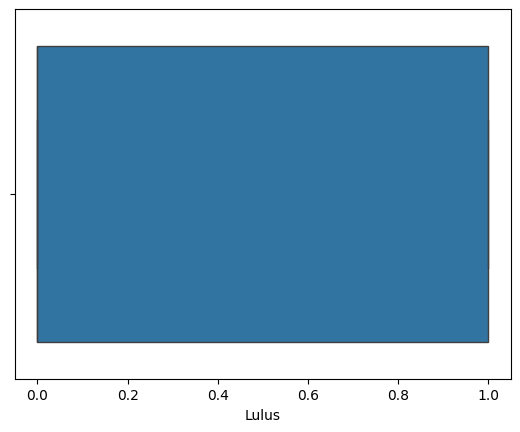

In [330]:
sns.boxplot(x=df['Lulus'])

#### menentkan outlier pada target lulus dengan scatter plot dan boxplot. tujuannya yaitu untuk menghilangkan nilai yang tidak masuk akal. dpat dilihat bahwa tidak ada nilai outlier

<Axes: xlabel='Jam_Belajar'>

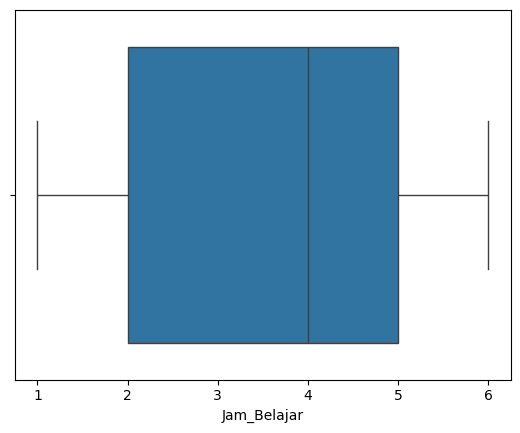

In [298]:
sns.boxplot(x=df['Jam_Belajar'])

#### menentukan outlier pada atribut jam belajar, dan terbukti tidak ada. jika ada maka akan dibuktikan adanya lingkaran-lingkarn diluar garis

<Axes: xlabel='Kehadiran'>

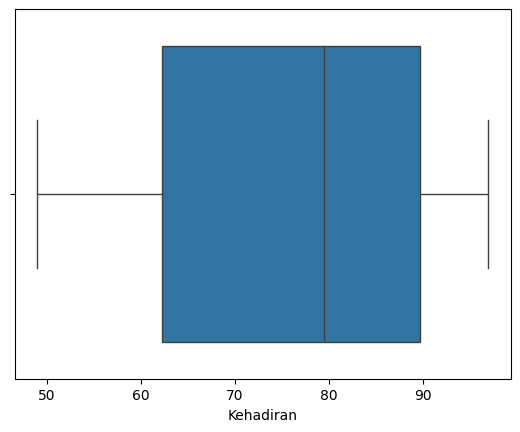

In [299]:
sns.boxplot(x=df['Kehadiran'])

#### menentukan outlier pada atribut kehadiran, dan terbukti tidak ada. jika ada maka akan dibuktikan adanya lingkaran-lingkarn diluar garis

<Axes: xlabel='Nilai_Tugas'>

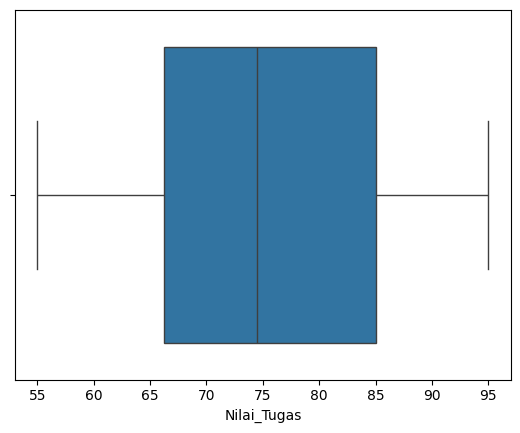

In [333]:
sns.boxplot(x=df['Nilai_Tugas'])

#### menentukan outlier pada atribut nilai tugas, dan terbukti tidak ada. jika ada maka akan dibuktikan adanya lingkaran-lingkarn diluar garis

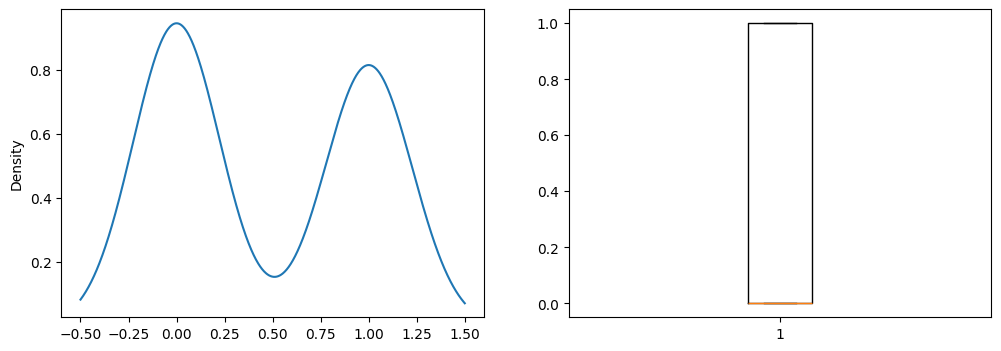

In [301]:
f= plt.figure(figsize=(12,4))
f.add_subplot(1,2,1)
df['Ikut_Bimbel'].plot(kind='kde')
f.add_subplot(1,2,2)
plt.boxplot(df['Ikut_Bimbel'])
plt.show()

<Axes: xlabel='Ikut_Bimbel'>

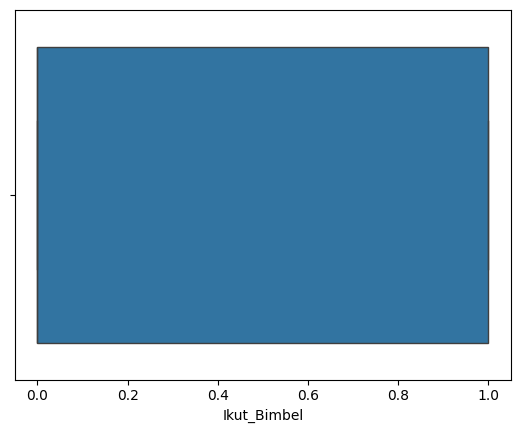

In [331]:
sns.boxplot(x=df['Ikut_Bimbel'])

#### menentukan outlier pada atribut ikut_bimbel, dan terbukti tidak ada. jika ada maka akan dibuktikan adanya lingkaran-lingkarn diluar garis

,ID,Jam_Belajar,Kehadiran,Nilai_Tugas,Ikut_Bimbel,Warna_Tas,Nomor_Kursi,Lulus
ID,1.000000,-0.027570,-0.002959,0.001948,0.081561,0.138855,0.119413,0.081561
Jam_Belajar,-0.027570,1.000000,0.989066,0.986140,-0.878335,-0.425134,-0.076258,-0.878335
Kehadiran,-0.002959,0.989066,1.000000,0.985296,-0.891361,-0.460634,-0.065600,-0.891361
Nilai_Tugas,0.001948,0.986140,0.985296,1.000000,-0.860447,-0.472916,-0.005197,-0.860447
Ikut_Bimbel,0.081561,-0.878335,-0.891361,-0.860447,1.000000,0.458740,0.263494,1.000000
Warna_Tas,0.138855,-0.425134,-0.460634,-0.472916,0.458740,1.000000,-0.063143,0.458740
Nomor_Kursi,0.119413,-0.076258,-0.065600,-0.005197,0.263494,-0.063143,1.000000,0.263494
Lulus,0.081561,-0.878335,-0.891361,-0.860447,1.000000,0.458740,0.263494,1.000000


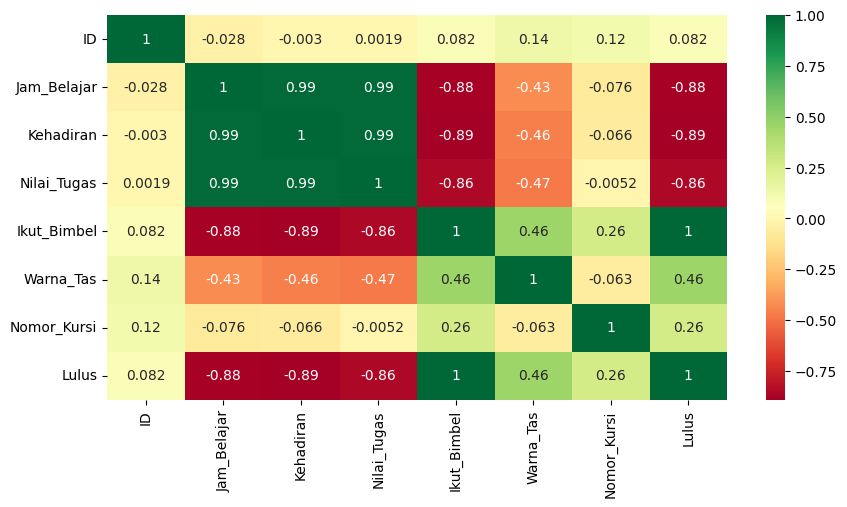

In [303]:
plt.figure(figsize=(10,5))
c= df.corr()
sns.heatmap(c, cmap="RdYlGn", annot=True)
c

#### melihat nilai korelasi antar atribut dengan target yaitu Lulus. Disini terlihat bahwa atribut ikut_bimbel sangat mempengaruhi kelulusan, semakin tinggi angka korelasi maka semakin tinggi pula korelasinya dan sebaliknya. meskipun begitu, bukan berarti juga kita langsung mengeleminasi atribut lainnya yang tidak memiliki korelasi tinggi, sebab kita juga harus menggunakan intuisi meskipun caranya benar belum tentu hasilya benar, misalnya apakah warna tas mempengaruhi kelulusan? tentu tidak

In [1]:
def train_test_split(x, y, test_size=0.2, seed=42):
    rng = np.random.default_rng(seed) #membuat generator angka acak dari numpy, seed digunakan agar pengcakan selalu sama setiap run
    idx = np.arange(len(x)) #Membuat array index dari data.
    rng.shuffle(idx) #Mengacak urutan index tersebut.
    split = int(len(x) * (1 - test_size)) #Menentukan titik pemisah data.
    train_idx, test_idx = idx[:split], idx[split:] #Membagi index menjadi dua bagian:
    return x[train_idx], x[test_idx], y[train_idx], y[test_idx] #mengembalikan nilai


def gini(y): #Mendefinisikan fungsi yang menerima label target.
    #gini impurity Fungsi ini menghitung Gini Impurity. Dipakai oleh Decision Tree untuk menentukan split terbaik.
    values, counts = np.unique(y, return_counts=True) #Menghitung kelas unik dan jumlahnya.
    p = counts / counts.sum() #Menghitung probabilitas setiap kelas.
    return 1.0 - np.sum(p ** 2) #Rumus Gini Impurity:


def majority_class(y): #Mendefinisikan fungsi.
    #kelas mayoritas (untuk leaf) Fungsi ini mencari kelas yang paling banyak muncul.Dipakai untuk leaf node pada Decision Tree.
    values, counts = np.unique(y, return_counts=True)#Menghitung jumlah tiap kelas.
    return values[np.argmax(counts)] #np.argmax() mencari index nilai terbesar.


def accuracy(y_true, y_pred): #Menghitung Accuracy (classification metric).
    """aakurasi sederhana."""
    return np.mean(y_true == y_pred)

#### pada bagian ini dilakukan plit data, gini, majority class, akurasi. data akan dipecah menjadi data training da testing dimana testing 20% dan sisanya 80% masuk training


In [305]:
# struktur node pada decision tree (simpul pada pohon)
class Node:
    
    # fungsi konstruktor untuk membuat objek node
    # tanda * berarti parameter setelahnya harus ditulis dengan nama (keyword argument)
    def __init__(self, *, feature_idx=None, threshold=None, left=None, right=None, value=None):
        
        # menyimpan index fitur yang digunakan untuk melakukan split
        # contoh: feature ke-0 = Jam_Belajar, feature ke-1 = Kehadiran
        self.feature_idx = feature_idx
        
        # nilai batas (threshold) yang digunakan untuk membagi data
        # contoh aturan: Jam_Belajar <= 3
        self.threshold = threshold
        
        # node anak kiri (data yang memenuhi kondisi <= threshold)
        self.left = left
        
        # node anak kanan (data yang tidak memenuhi kondisi > threshold)
        self.right = right
        
        # nilai kelas jika node ini adalah leaf node
        # contoh: 0 = Tidak Lulus, 1 = Lulus
        self.value = value

#### Secara umum, class Node digunakan untuk menyimpan struktur setiap simpul (node) pada pohon keputusan dalam algoritma Decision Tree.Artinya, Node adalah blok dasar pembentuk pohon keputusan.

In [353]:
# membuat class Decision Tree classifier dari nol
class DecisionTreeClassifierScratch:

    # fungsi konstruktor, dijalankan saat objek dibuat
    def __init__(self, max_depth=5, min_samples_split=2, min_impurity_decrease=1e-7):
        
        # batas maksimal kedalaman pohon (agar tidak terlalu kompleks / overfitting)
        self.max_depth = max_depth
        
        # jumlah minimal data agar sebuah node boleh di-split
        # jika data kurang dari ini maka node menjadi leaf
        self.min_samples_split = min_samples_split
        
        # minimal penurunan impurity agar split dianggap berguna
        # jika gain lebih kecil dari ini maka tidak dilakukan split
        self.min_impurity_decrease = min_impurity_decrease
        
        # root adalah node pertama dari pohon decision tree
        # awalnya kosong karena tree belum dibuat
        self.root = None


    # fungsi untuk melatih model menggunakan data training
    def fit(self, X, y):
        
        # memanggil fungsi _build_tree untuk membangun pohon dari data
        # depth dimulai dari 0 karena masih root
        self.root = self._build_tree(X, y, depth=0)


    # fungsi untuk memprediksi banyak data sekaligus
    def predict(self, X):
        
        # melakukan prediksi untuk setiap baris data X
        # _predict_one dipanggil untuk tiap sampel
        return np.array([self._predict_one(x, self.root) for x in X])


    # fungsi untuk memprediksi satu data saja
    def _predict_one(self, x, node):
        
        # selama node belum leaf (value masih None)
        # maka model akan terus turun ke node berikutnya
        while node.value is None:
            
            # jika nilai fitur <= threshold
            if x[node.feature_idx] <= node.threshold:
                
                # pindah ke cabang kiri
                node = node.left
            else:
                
                # jika tidak memenuhi kondisi pindah ke cabang kanan
                node = node.right
        
        # jika sudah sampai leaf node maka kembalikan nilai kelas
        return node.value

In [307]:
# fungsi untuk mencari split terbaik berdasarkan Gini Gain
def best_split(x, y):

    # fungsi ini akan mengembalikan:
    # feature terbaik, threshold terbaik, dan gain terbesar
    """mengembalikan (best_feature, best_threshold, best_gain)"""

    # mengambil jumlah data (baris) dan jumlah fitur (kolom)
    n_samples, n_features = x.shape

    # menghitung impurity dari node saat ini (sebelum split)
    parent_impurity = gini(y)

    # nilai awal gain terbaik
    best_gain = 0.0

    # menyimpan index fitur terbaik
    best_feature = None

    # menyimpan nilai threshold terbaik
    best_thresh = None


    # looping semua fitur
    for f in range(n_features):

        # mengambil semua nilai unik dari fitur ke-f
        values = np.unique(x[:, f])

        # jika hanya ada satu nilai unik maka tidak bisa split
        if len(values) == 1:
            continue


        # membuat kandidat threshold
        # midpoint dari nilai unik yang sudah diurutkan
        thresholds = (values[:-1] + values[1:]) / 2.0


        # mencoba setiap threshold
        for t in thresholds:

            # membuat mask untuk data yang masuk cabang kiri
            left_mask = x[:, f] <= t

            # data yang tidak masuk kiri akan masuk kanan
            right_mask = ~left_mask


            # jika salah satu cabang kosong maka skip
            if left_mask.sum() == 0 or right_mask.sum() == 0:
                continue


            # label data yang masuk cabang kiri
            y_left = y[left_mask]

            # label data yang masuk cabang kanan
            y_right = y[right_mask]


            # menghitung bobot jumlah data kiri
            w_left = len(y_left) / n_samples

            # menghitung bobot jumlah data kanan
            w_right = len(y_right) / n_samples


            # impurity setelah split
            # dihitung dari impurity kiri + kanan
            child_impurity = w_left * gini(y_left) + w_right * gini(y_right)


            # menghitung Gini Gain
            gain = parent_impurity - child_impurity


            # jika gain lebih besar dari sebelumnya
            if gain > best_gain:

                # simpan gain terbaik
                best_gain = gain

                # simpan fitur terbaik
                best_feature = f

                # simpan threshold terbaik
                best_thresh = t


    # mengembalikan fitur terbaik, threshold terbaik, dan gain terbesar
    return best_feature, best_thresh, best_gain

In [354]:
# membuat fungsi _best_split yang nantinya akan menjadi method di dalam class
def _best_split(self, X, y):
    
    # fungsi ini hanya memanggil fungsi best_split yang sudah dibuat sebelumnya
    # X = data fitur
    # y = label target
    return best_split(X, y)


# menempelkan fungsi _best_split ke dalam class DecisionTreeClassifierScratch
# sehingga class tersebut sekarang memiliki method bernama _best_split
DecisionTreeClassifierScratch._best_split = _best_split

In [309]:
#bangn tree rekursif
def _build_tree(self, X, y, depth):
    # (A) stop jika semua label sama => leaf
    if len(np.unique(y)) == 1:
        return Node(value=y[0])

    # (B) stop jika depth mentok / data terlalu sedikit => leaf mayoritas
    if depth >= self.max_depth or len(y) < self.min_samples_split:
        return Node(value=majority_class(y))

    # (C) cari split terbaik
    feature, thresh, gain = self._best_split(X, y)

    # (D) jika tidak ada split bagus => leaf mayoritas
    if feature is None or gain < self.min_impurity_decrease:
        return Node(value=majority_class(y))

    # (E) split data
    left_mask = X[:, feature] <= thresh
    right_mask = ~left_mask

    left = self._build_tree(X[left_mask], y[left_mask], depth + 1)
    right = self._build_tree(X[right_mask], y[right_mask], depth + 1)

    return Node(feature_idx=feature, threshold=thresh, left=left, right=right)

DecisionTreeClassifierScratch._build_tree = _build_tree

In [310]:
# split data
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.25, seed=123)

# satih model
tree = DecisionTreeClassifierScratch(max_depth=4, min_samples_split=3)
tree.fit(X_train, y_train)

# prediksi
y_pred = tree.predict(X_test)

print("Accuracy:", accuracy(y_test, y_pred))

# lihat 10 hasil pertama
pd.DataFrame({"y_true": y_test[:10], "y_pred": y_pred[:10]})

Accuracy: 1.0


,y_true,y_pred
0,1,1
1,0,0
2,1,1
3,0,0
4,0,0
5,1,1
6,1,1
7,0,0
8,0,0
9,0,0


In [311]:
def confusion_matrix_df(y_true, y_pred, labels=None):
    """cconfusion matrix dalam bentuk DataFrame"""
    if labels is None:
        labels = np.unique(np.concatenate([y_true, y_pred]))
    labels = list(labels)
    label_to_idx = {lab: i for i, lab in enumerate(labels)}
    cm = np.zeros((len(labels), len(labels)), dtype=int)
    for yt, yp in zip(y_true, y_pred):
        cm[label_to_idx[yt], label_to_idx[yp]] += 1
    return pd.DataFrame(cm, index=[f"True_{l}" for l in labels], columns=[f"Pred_{l}" for l in labels])

def classification_report_df(y_true, y_pred, labels=None):
    """hitung precision/recall/F1 per kelas + macro & weighted avg"""
    if labels is None:
        labels = np.unique(np.concatenate([y_true, y_pred]))
    labels = list(labels)
    
    rows = []
    support_total = 0
    macro_p = macro_r = macro_f1 = 0.0
    weighted_p = weighted_r = weighted_f1 = 0.0
    
    for lab in labels:
        tp = np.sum((y_true == lab) & (y_pred == lab))
        fp = np.sum((y_true != lab) & (y_pred == lab))
        fn = np.sum((y_true == lab) & (y_pred != lab))
        support = np.sum(y_true == lab)
        support_total += support
        
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = (2 * precision * recall / (precision + recall)) if (precision + recall) > 0 else 0.0
        
        rows.append([lab, precision, recall, f1, support])
        
        macro_p += precision
        macro_r += recall
        macro_f1 += f1
        
        weighted_p += precision * support
        weighted_r += recall * support
        weighted_f1 += f1 * support
    
    n_classes = len(labels)
    macro_p /= n_classes
    macro_r /= n_classes
    macro_f1 /= n_classes
    
    if support_total > 0:
        weighted_p /= support_total
        weighted_r /= support_total
        weighted_f1 /= support_total
    
    report = pd.DataFrame(rows, columns=["class", "precision", "recall", "f1_score", "support"])
    
    # Tambahkan ringkasan
    summary = pd.DataFrame([
        ["macro_avg", macro_p, macro_r, macro_f1, support_total],
        ["weighted_avg", weighted_p, weighted_r, weighted_f1, support_total],
    ], columns=report.columns)
    
    report = pd.concat([report, summary], ignore_index=True)
    return report

# --- Hitung metrik ---
labels = np.unique(np.concatenate([y_test, y_pred]))
cm = confusion_matrix_df(y_test, y_pred, labels=labels)
report = classification_report_df(y_test, y_pred, labels=labels)

print("Akurasi:", accuracy(y_test, y_pred))
print("\nConfusion Matrix:")
display(cm)

print("\nPrecision / Recall / F1 per kelas:")
display(report)

Akurasi: 1.0

Confusion Matrix:


,Pred_0,Pred_1
True_0,8,0
True_1,0,6



Precision / Recall / F1 per kelas:


,class,precision,recall,f1_score,support
0,0,1.0,1.0,1.0,8
1,1,1.0,1.0,1.0,6
2,macro_avg,1.0,1.0,1.0,14
3,weighted_avg,1.0,1.0,1.0,14


In [337]:
contoh = np.array([
    [4.0, 82.0, 78.0, 0]
], dtype=float)

pred_contoh = tree.predict(contoh)
pd.DataFrame(contoh, columns=FEATURE).assign(prediksi_lulus=pred_contoh)

,Jam_Belajar,Kehadiran,Nilai_Tugas,Ikut_Bimbel,prediksi_lulus
0,4.0,82.0,78.0,0.0,0


In [335]:
df[df["Lulus"] == 1].head()

,ID,Jam_Belajar,Kehadiran,Nilai_Tugas,Ikut_Bimbel,Warna_Tas,Nomor_Kursi,Lulus
1,2,2.0,60.0,65.0,1,Biru,7,1
3,4,1.0,50.0,60.0,1,Hijau,18,1
9,10,1.0,55.0,58.0,1,Merah,11,1
11,12,3.0,68.0,69.0,1,Hitam,10,1
16,17,1.0,52.0,60.0,1,Hitam,13,1


In [314]:
print(X_test)

[[ 2. 63. 67.  1.]
 [ 4. 82. 78.  0.]
 [ 3. 74. 72.  1.]
 [ 5. 89. 84.  0.]
 [ 6. 92. 88.  0.]
 [ 3. 72. 70.  1.]
 [ 1. 52. 56.  1.]
 [ 5. 88. 82.  0.]
 [ 5. 91. 87.  0.]
 [ 4. 83. 76.  0.]
 [ 2. 63. 68.  1.]
 [ 3. 72. 70.  1.]
 [ 6. 97. 94.  0.]
 [ 4. 84. 79.  0.]]


In [352]:
import tkinter as tk
import numpy as np

# fungsi prediksi
def prediksi_kelulusan():

    jam = float(entry_jam.get())
    hadir = float(entry_hadir.get())
    tugas = float(entry_tugas.get())
    bimbel = float(entry_bimbel.get())

    data = np.array([[jam, hadir, tugas, bimbel]])

    pred = tree.predict(data)[0]

    if pred == 1:
        hasil = "Lulus"
    else:
        hasil = "Tidak Lulus"

    label_hasil.config(text=f"Prediksi : {hasil}")


root = tk.Tk()
root.title("Prediksi Kelulusan Siswa")
root.geometry("300x250")

# Jam Belajar
tk.Label(root, text="Jam Belajar").pack()
entry_jam = tk.Entry(root)
entry_jam.pack()

# Kehadiran
tk.Label(root, text="Kehadiran").pack()
entry_hadir = tk.Entry(root)
entry_hadir.pack()

# Nilai Tugas
tk.Label(root, text="Nilai Tugas").pack()
entry_tugas = tk.Entry(root)
entry_tugas.pack()

# Ikut Bimbel
tk.Label(root, text="Ikut Bimbel (0 / 1)").pack()
entry_bimbel = tk.Entry(root)
entry_bimbel.pack()

# tombol prediksi
tk.Button(root, text="Prediksi", command=prediksi_kelulusan).pack(pady=10)

# hasil
label_hasil = tk.Label(root, text="")
label_hasil.pack()

root.mainloop()